In [11]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
all_events = pd.read_csv('data/psi_response.csv')
all_events

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
2,ENSG00000160072;SE:chr1:1489274-1489692:148981...,ENSG00000160072,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
4,ENSG00000197530;SE:chr1:1625653-1626650:162675...,ENSG00000197530,0.089905,0.120574,0.064458,0.089905,0.833147,1.226858,0.938053,0.926230
...,...,...,...,...,...,...,...,...,...,...
24946,ENSG00000259207;AR:chr17:47284695-47286260:472...,ENSG00000259207,0.201397,1.089905,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24947,ENSG00000259207;AR:chr17:47290274-47290954:472...,ENSG00000259207,0.120574,1.070407,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24948,ENSG00000259207;AR:chr17:47291088-47292139:472...,ENSG00000259207,0.120574,1.070407,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24949,ENSG00000259305;AR:chr8:123231757-123237798:12...,ENSG00000259305,0.733197,0.445604,-1.000000,-1.000000,0.744293,0.460898,1.000000,1.000000


In [4]:
se_events = all_events[all_events['event_id'].str.contains(';SE:')]['event_id']
ar_events = all_events[all_events['event_id'].str.contains(';AR:')]['event_id']

se_events

0       ENSG00000224051;SE:chr1:1325102-1326836:132703...
1       ENSG00000160072;SE:chr1:1486668-1487863:148791...
2       ENSG00000160072;SE:chr1:1489274-1489692:148981...
3       ENSG00000197530;SE:chr1:1624901-1624991:162518...
4       ENSG00000197530;SE:chr1:1625653-1626650:162675...
                              ...                        
7168    ENSG00000071889;SE:chrX:154507490-154507811:15...
7169    ENSG00000071889;SE:chrX:154511871-154512823:15...
7170    ENSG00000071889;SE:chrX:154511871-154512314:15...
7171    ENSG00000130830;SE:chrX:154792285-154799745:15...
7172    ENSG00000155962;SE:chrX:155299145-155309572:15...
Name: event_id, Length: 7173, dtype: object

In [23]:
def exonic_overlap(current_event, events):
    event_split = current_event.split(':')
    exon_chr = event_split[1]
    exon_start = int(event_split[2].split("-")[1])
    exon_end = int(event_split[3].split("-")[0])
    overlap = []
    for event in events:
        event_split = event.split(':')
        if event_split[1] != exon_chr:
            continue
        event_exon_start = int(event_split[2].split("-")[1])
        event_exon_end = int(event_split[3].split("-")[0])
        if (exon_start <= event_exon_end and exon_end >= event_exon_start):
            # return the number of overlapping bases
            overlap_start = max(exon_start, event_exon_start)
            overlap_end = min(exon_end, event_exon_end)
            overlap_length = overlap_end - overlap_start
            overlap.append(overlap_length)
    return overlap

def event_overlap(current_event, events):
    event_split = current_event.split(':')
    event_chr = event_split[1]

    event_start = int(event_split[2].split("-")[0])
    event_end = int(event_split[3].split("-")[1])
    
    overlap = []
    for event in events:
        event_split = event.split(':')
        if event_split[1] != event_chr:
            continue
        event_start_pos = int(event_split[2].split("-")[0])
        event_end_pos = int(event_split[3].split("-")[1])
        if (event_start <= event_end_pos and event_end >= event_start_pos):
            # return the number of overlapping bases
            overlap_start = max(event_start, event_start_pos)
            overlap_end = min(event_end, event_end_pos)
            overlap_length = overlap_end - overlap_start
            overlap.append(overlap_length)
    return overlap


In [15]:
exon_overlaps = defaultdict(int)
average_base_overlap = 0
for event in se_events:
    overlap = exonic_overlap(event, se_events)
    if overlap:
        exon_overlaps[len(overlap)] += 1
        average_base_overlap += np.mean(overlap)

print(f"Possible exon overlaps: {exon_overlaps.keys()}\nAverage overlap length: {average_base_overlap / len(se_events):.2f} bases")

Possible exon overlaps: dict_keys([1, 2, 3, 4, 7, 5, 9, 11])
Average overlap length: 134.60 bases


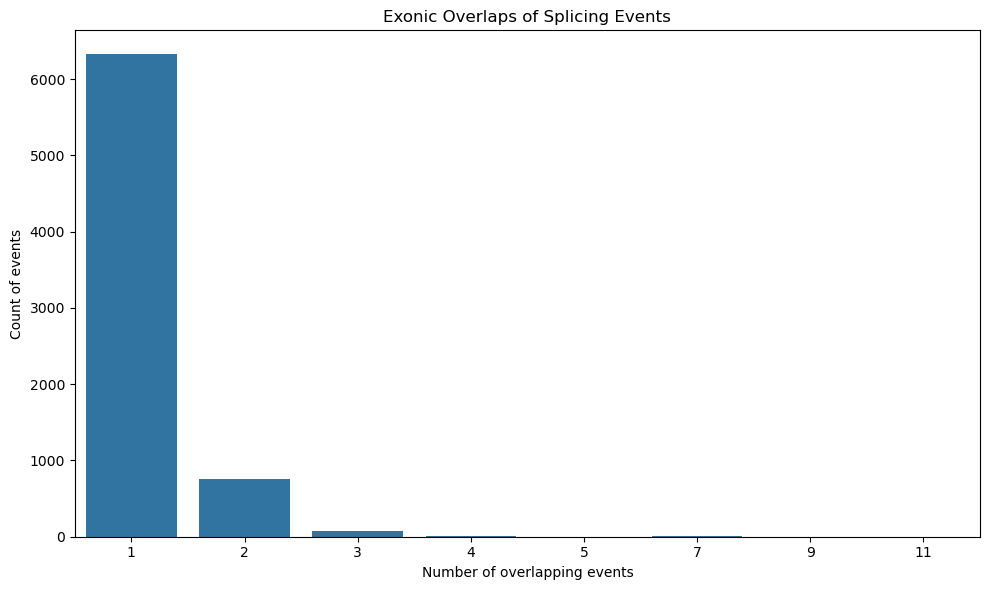

In [16]:
# plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(exon_overlaps.keys()), y=list(exon_overlaps.values()))
plt.xlabel('Number of overlapping events')
plt.ylabel('Count of events')
plt.title('Exonic Overlaps of Splicing Events')
plt.tight_layout()
plt.show()

In [17]:
exon_overlaps = defaultdict(int)
average_base_overlap = 0
for event in ar_events:
    overlap = exonic_overlap(event, ar_events)
    if overlap:
        exon_overlaps[len(overlap)] += 1
        average_base_overlap += np.mean(overlap)

print(f"Possible exon overlaps: {exon_overlaps.keys()}\nAverage overlap length: {average_base_overlap / len(se_events):.2f} bases")

Possible exon overlaps: dict_keys([1, 3, 2, 6, 4, 5])
Average overlap length: 412.58 bases


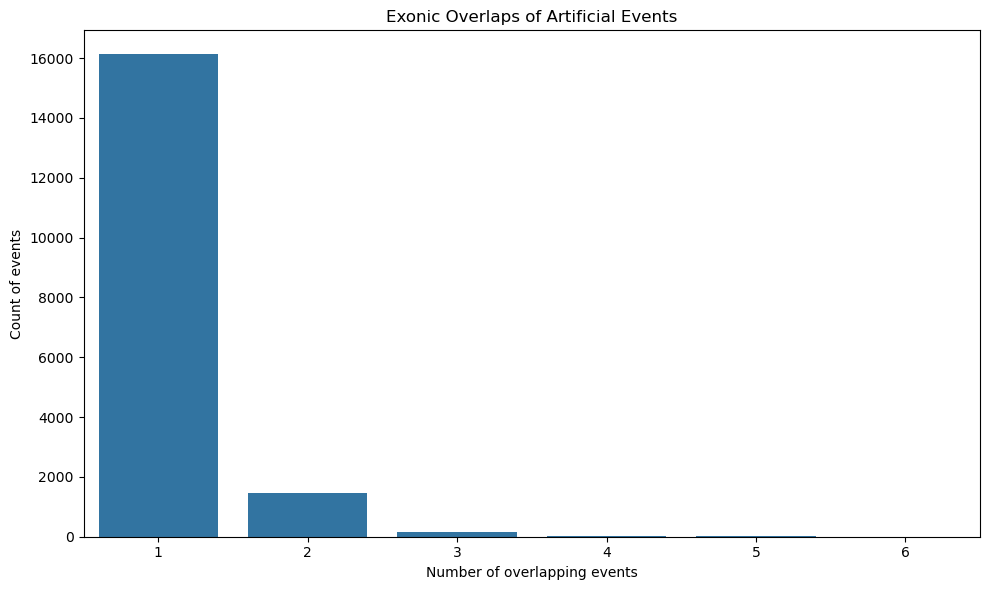

In [19]:
# plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(exon_overlaps.keys()), y=list(exon_overlaps.values()))
plt.xlabel('Number of overlapping events')
plt.ylabel('Count of events')
plt.title('Exonic Overlaps of Artificial Events')
plt.tight_layout()
plt.show()

### Whole event overlap

In [32]:
event_overlaps = defaultdict(int)
average_base_overlap = 0
for event in se_events:
    overlap = event_overlap(event, se_events)
    if overlap:
        event_overlaps[len(overlap)] += 1
        average_base_overlap += np.mean(overlap)

print(f"Possible exon overlaps: {event_overlaps.keys()}\nAverage overlap length: {average_base_overlap / len(se_events):.2f} bases")

Possible exon overlaps: dict_keys([1, 2, 3, 7, 10, 9, 4, 5, 6, 8, 11])
Average overlap length: 10807.19 bases


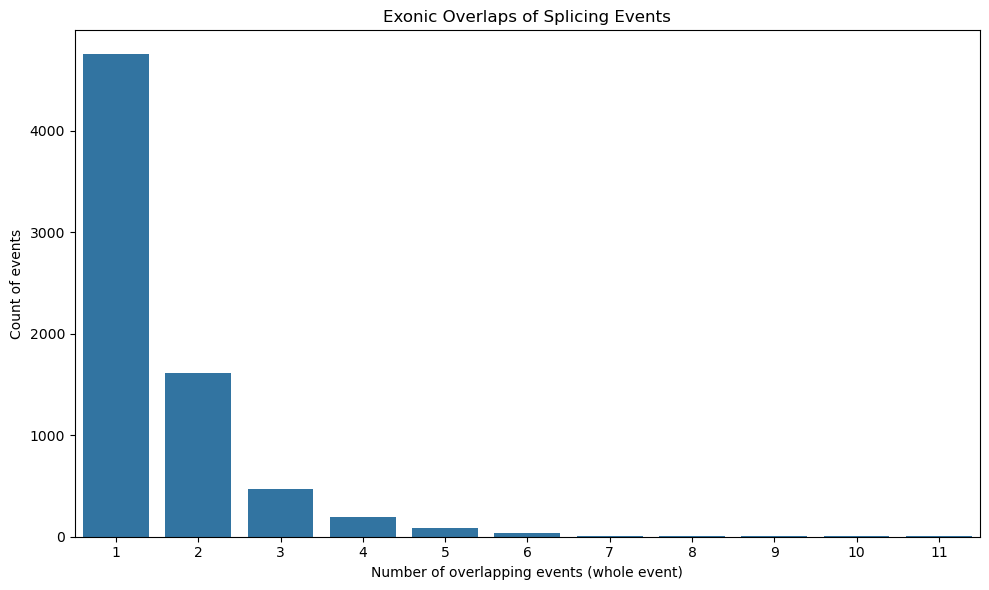

In [33]:
# plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(event_overlaps.keys()), y=list(event_overlaps.values()))
plt.xlabel('Number of overlapping events (whole event)')
plt.ylabel('Count of events')
plt.title('Exonic Overlaps of Splicing Events')
plt.tight_layout()
plt.show()

In [34]:
event_overlaps = defaultdict(int)
average_base_overlap = 0
for event in ar_events:
    overlap = event_overlap(event, ar_events)
    if overlap:
        event_overlaps[len(overlap)] += 1
        average_base_overlap += np.mean(overlap)

print(f"Possible exon overlaps: {event_overlaps.keys()}\nAverage overlap length: {average_base_overlap / len(se_events):.2f} bases")

Possible exon overlaps: dict_keys([2, 4, 1, 3, 5, 6, 7, 8, 10])
Average overlap length: 22805.95 bases


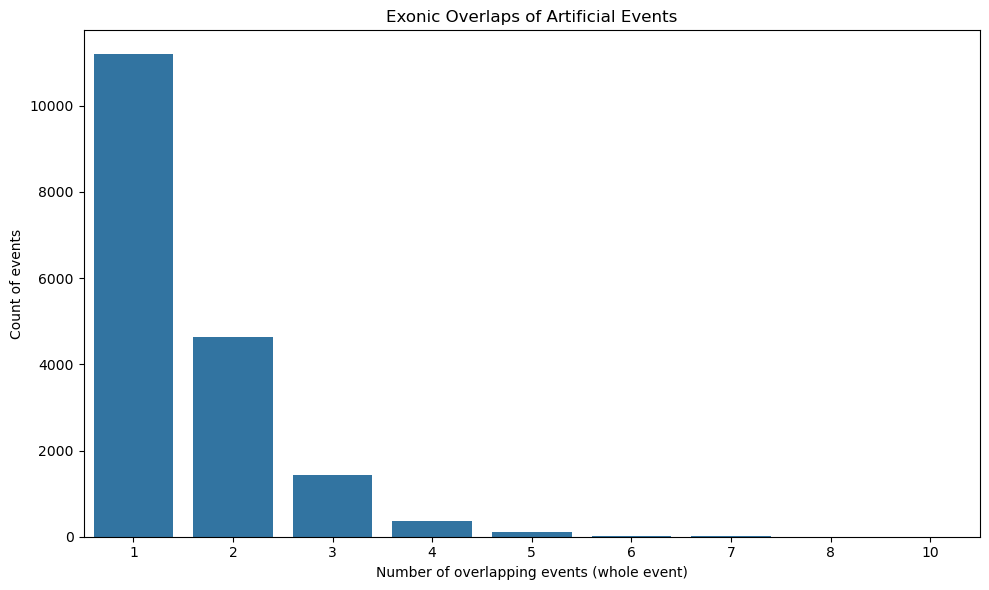

In [35]:
# plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(event_overlaps.keys()), y=list(event_overlaps.values()))
plt.xlabel('Number of overlapping events (whole event)')
plt.ylabel('Count of events')
plt.title('Exonic Overlaps of Artificial Events')
plt.tight_layout()
plt.show()